# ДЗ Линейная регрессия

В данном задании мы рассмотрим набор данных об учащихся, собранный в 2006 году в одной из школ Португалии. Данные представлены в неудобном для машинного обучения виде, и содержат мусор. Ваша задача &mdash; привести их к надлежащему виду и обучить на них простую модель.

Данные состоят из четырех файлов:
- data.csv &mdash; основная таблица с информацией о учащихся
- scores.csv &mdash; список финальных оценок по одному из предметов (20-балльная шкала переведенная в проценты)
- attendance.csv &mdash; таблица посещений занятий по этому предмету
- school_support.txt &mdash; список учащихся, которым оказывается финансовая поддержка

Ваша задача &mdash; построить модель для предсказания финальных оценок исходя из всех остальных данных и проверить качество ее работы с помощью кросс-валидации. В качестве алгоритма мы будем использовать линейную регрессию

Расшифровка столбцов в data.csv для справки:
- age &mdash; возраст
- Medu &mdash; уровень образования матери (по некоторой условной шкале)
- Fedu &mdash; уровень образования отца (по некоторой условной шкале)
- traveltime &mdash; время в пути до школы (1 – < 15 мин., 2 – от 15 до 30 мин., 3 – от 30 мин. to 1 ч.
или 4 – > 1 ч.)
- studytime &mdash; время, затрачиваемое на занятия вне школы (1 – < 2 ч., 2 – от 2 до 5 ч., 3 – от 5 до 10 ч. или 4 – > 10 ч.)
- famrel &mdash; насколько хорошие отношения в семье у учащегося (по некоторой условной шкале)
- freetime &mdash; количество свободного времени вне школы (по некоторой условной шкале)
- goout &mdash; время, затрачиваемое на общение с друзьями (по некоторой условной шкале)
- Dalc &mdash; количество употребления алкоголя в учебные дни (по некоторой условной шкале)
- Walc &mdash; количество употребления алкоголя в неучебные дни (по некоторой условной шкале)
- health &mdash; уровень здоровья (по некоторой условной шкале)
- sex_M &mdash; пол: мужской (1) или женский (0)
- address_U &mdash; живет ли учащийся в городе (1) или в пригороде (0)
- famsize_LE3 &mdash; размер семьи: не больше 3 человек (1) или больше (0)
- Pstatus_T &mdash; живут ли родители вместе (1) или отдельно (0)
- nursery &mdash; посещал ли учащийся детский сад
- plans_university &mdash; планирует ли учащийся поступать в университет (-1 или 1)
- past_failures &mdash; количество неудовлетворительных оценок по другим предметам ранее (от 0 до 4)

*Примечание. Несколько признаков в данных содержат ошибки/проблемы/некорректности. Эти проблемы нужно исправить. Для
проверки &mdash; всего в данных таких проблем четыре.*

Начиная с 4 пункта делайте кроссвалидацию на 4 батча до и после, замеряйте результат

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

### Задача 1: сломанный признак (а может и не один)
__(1 балл)__

Загрузите таблицу data.csv.

Найдите в данных сломанный признак (он не соответствует описанию) и исправьте его.

In [44]:
data = pd.read_csv('data.csv')

data = data.rename(columns={'plans_universitypast_failures': 'plans_past'})

def split_plans_past(x):
    x = str(x).replace('.0', '')
    if x.startswith('-'):
        return pd.Series([-1, int(x[2:])])
    return pd.Series([1, int(x[1:])])

data[['plans_university', 'past_failures']] = data['plans_past'].apply(split_plans_past)
data = data.drop(columns=['plans_past'])

mask_age = data['age'] > 100
data.loc[mask_age, 'age'] = 2006 - data.loc[mask_age, 'age']

data['traveltime'] = data['traveltime'].replace({10: 1, 25: 2, 40: 3, 50: 3})

print(data.head())

   age  Medu  Fedu  traveltime  studytime  famrel  freetime  goout  Dalc  \
0   16     4     4           1          2       5         4    4.0   1.0   
1   17     4     4           1          1       5         3    4.0   1.0   
2   16     1     1           2          1       4         5    5.0   2.0   
3   18     1     2           2          1       3         4    4.0   2.0   
4   17     2     1           2          2       4         2    5.0   1.0   

   Walc  health  sex_M  address_U  famsize_LE3  Pstatus_T  nursery  \
0   2.0       5      1          1            0          1        1   
1   2.0       5      0          1            0          1        1   
2   4.0       5      1          0            1          1        1   
3   4.0       4      1          1            0          1        0   
4   2.0       5      0          0            0          1        1   

   plans_university  past_failures  
0                 1              0  
1                 1              0  
2          

### Задача 2: пропуски в данных 
__(1 балл)__

Проверьте, есть ли в данных пропуски (значения NaN). Замените все пропущенные значения на среднее значение этого признака по столбцу.

*Hint: изучите в pandas функции loc, isnull, а также передачу булевых массивов в качестве индексов.*

In [45]:
print(data.isnull().sum())
data = data.fillna(data.mean(numeric_only=True))
print('Пропусков осталось:', data.isnull().sum().sum())

age                  0
Medu                 0
Fedu                 0
traveltime           0
studytime            0
famrel               0
freetime             0
goout                1
Dalc                10
Walc                 6
health               0
sex_M                0
address_U            0
famsize_LE3          0
Pstatus_T            0
nursery              0
plans_university     0
past_failures        0
dtype: int64
Пропусков осталось: 0


### Задача 3: нормализация данных
__(1 балл)__

Нормализуйте данные любым способом, в современных библиотеках нормализация часто встроена внутрь модели, поэтому тут разницы может и не быть в качестве, но сделать надо

In [46]:
scaler = StandardScaler()
data_scaled = pd.DataFrame(scaler.fit_transform(data), columns=data.columns)
print(data_scaled.describe())

                age          Medu          Fedu    traveltime     studytime  \
count  6.490000e+02  6.490000e+02  6.490000e+02  6.490000e+02  6.490000e+02   
mean  -1.368534e-16 -1.245366e-16 -4.926722e-17 -7.663789e-17  9.306030e-17   
std    1.000771e+00  1.000771e+00  1.000771e+00  1.000771e+00  1.000771e+00   
min   -1.432980e+00 -2.218124e+00 -2.098682e+00 -7.600319e-01 -1.122808e+00   
25%   -6.114218e-01 -4.539544e-01 -1.188832e+00 -7.600319e-01 -1.122808e+00   
50%    2.101367e-01 -4.539544e-01 -2.789831e-01 -7.600319e-01  8.365295e-02   
75%    1.031695e+00  1.310216e+00  6.308662e-01  5.767180e-01  8.365295e-02   
max    4.317929e+00  1.310216e+00  1.540715e+00  3.250218e+00  2.496576e+00   

             famrel      freetime         goout          Dalc          Walc  \
count  6.490000e+02  6.490000e+02  6.490000e+02  6.490000e+02  6.490000e+02   
mean  -1.696982e-16  1.806465e-16  5.145687e-16  1.847521e-16  1.012715e-16   
std    1.000771e+00  1.000771e+00  1.000771e+00  1.

### Задача 4: кросс-валидация для исходных данных
__(1 балл)__

Загрузите файл scores.csv и протестируйте, как линейная регрессия предсказывает ответ сейчас (с помощью кросс-валидации).

Кроссвалидацию сделайте по 4 разбивкам. Выведите качество в каждом их разбиений.

*Hint: воспользуйтесь sklearn.linear_model и sklearn.model_selection.*

In [47]:
scores = pd.read_csv('scores.csv', header=None, names=['score'])
scores.loc[scores['score'] < 1, 'score'] *= 100

y = scores['score'].values.copy()
X = data.values

kf = KFold(n_splits=4, shuffle=True, random_state=42)
model = make_pipeline(StandardScaler(), LinearRegression())

r2 = cross_val_score(model, X, y, cv=kf, scoring='r2')
mse = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')

print('R2 по фолдам:', r2)
print('MSE по фолдам:', mse)
print('Средний R2:', r2.mean())
print('Средний MSE:', mse.mean())

R2 по фолдам: [0.24422004 0.31579909 0.25807734 0.1241239 ]
MSE по фолдам: [191.0684783  209.95887478 168.51007578 219.78419399]
Средний R2: 0.23555509108229628
Средний MSE: 197.33040571267293


### Задача 5: полные данные
__(2 балла)__

Воспользуйтесь файлами attendance.csv и school_support.txt для того, чтобы добавить новые признаки в данные. Желательно по максимуму использовать возможности pandas для упрощения преобразований.

school_suport число в строке значит что i-ый школьник из исходной таблицы получал мат помощь (обратите внимание что строк в файле меньше, подумайте как правильно импортировать данные)

Добавьте данные таким образом, чтобы качество выросло

In [48]:
att = pd.read_csv('attendance.csv', sep=';')
att = att.replace({'+': 1, np.nan: 0}).fillna(0)
att['attendance_count'] = att.sum(axis=1)

with open('school_support.txt', 'r') as f:
    support_ids = [int(line.strip()) for line in f if line.strip()]

data['school_support'] = 0
support_ids_zero = [i - 1 for i in support_ids if 0 <= i - 1 < len(data)]
data.loc[support_ids_zero, 'school_support'] = 1
data['attendance_count'] = att['attendance_count'].values

X = data.values

r2_new = cross_val_score(model, X, y, cv=kf, scoring='r2')
mse_new = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')

print('R2 после добавления признаков:', r2_new)
print('MSE после добавления признаков:', mse_new)
print('Средний R2:', r2_new.mean())
print('Средний MSE:', mse_new.mean())

R2 после добавления признаков: [0.24396705 0.30915686 0.25643558 0.10823399]
MSE после добавления признаков: [191.13243671 211.99715782 168.88296039 223.77145813]
Средний R2: 0.2294483727490006
Средний MSE: 198.94600326338855


### Задача 6: борьба с выбросами
__(1.5 балла)__

Качество предсказания может ухудшаться, если в данных присутствуют корректные значения признаков (с точки зрения чтения данных и применения методов), но не соответствующие реальным объектам. Например, данные могли быть введены в неверном формате, а потом слишком грубо приведены к общему виду, из-за чего ошибка не была замечена.
Попробуем от такого избавиться &mdash; а для этого такие объекты нужно сначала найти. Конечно, нам еще недоступны многие продвинутые способы, но давайте попробуем обойтись простыми.

Первый способ это сделать &mdash; посмотреть для каждого признака на распределение его значений и проверить крайние значения на правдоподобность. (постройте гистограммы для признаков, как минимум для подозрительных)

*Hint 1: используйте функцию DataFrame.hist*

*Hint 2: в описании датасета выше есть информация, необходимая для восстановления правильных значений*

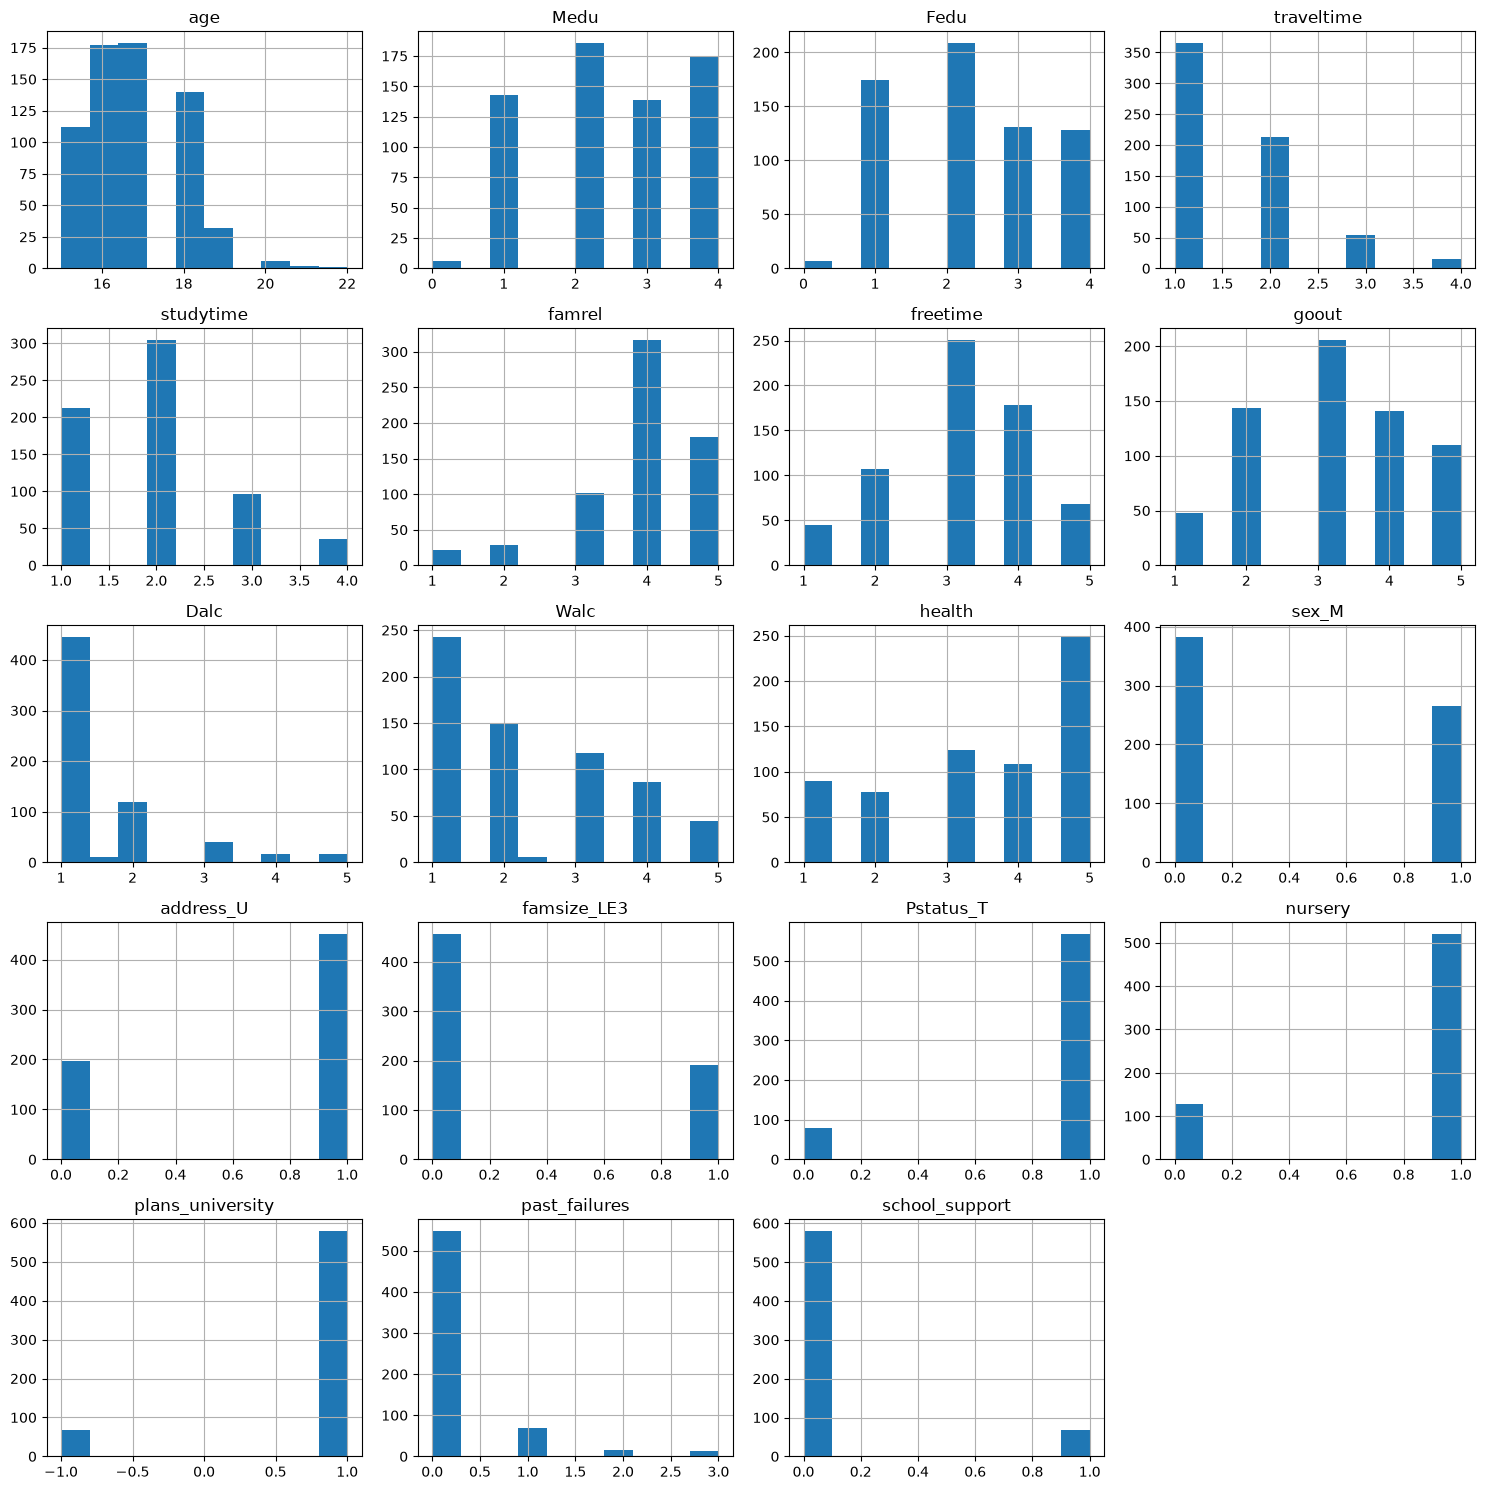

In [49]:
data.hist(figsize=(15, 15))
plt.tight_layout()
plt.show()

__(1.5 балла)__

Другой простой способ найти выбросы &mdash; сделать предсказание и посчитать ошибку на каждом объекте по отдельности и посмотреть на объекты с наибольшей ошибкой. Обучите линейную регрессию (функция fit) и для каждого объекта посчитайте среднеквадратичное отклонение. Постройте гистограмму распределения ошибок. Посмотрите на гистограмму и удалите из выборки те объекты на которых ошибка слишком большая.

Обратите внимание, что просто удалять все объекты с высокой ошибкой нельзя &mdash; это, конечно, хороший способ добиться меньшей ошибки (на данной выборке), но одновременно вы ухудшите обобщающую способность алгоритма. Вместо этого вам нужно найти однозначно ошибочные записи и их исправить.

*Hint: возможно, все проблемы уже были найдены первым способом; для проверки &mdash; в сумме здесь нужно исправить 3 проблемы.*

Для поиска ошибки на одном отдельном обьекте придётся обучить линейную регрессию руками. Частичный пример, допишите код. Постройте гистограмму распределения ошибок

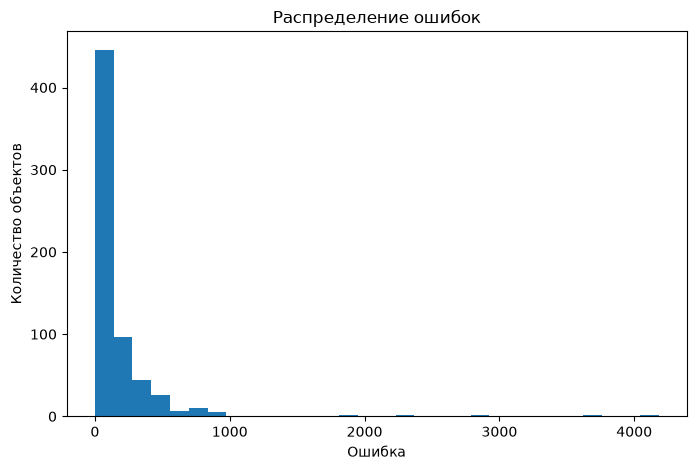

Объекты с наибольшей ошибкой:
     age  Medu  Fedu  traveltime  studytime  famrel  freetime  goout  Dalc  \
303   18     2     1           2          1       4         4    3.0   1.0   
385   16     2     1           2          2       5         2    1.0   1.0   
615   18     4     4           3          2       3         2    2.0   4.0   
319   17     4     2           1          2       5         5    5.0   1.0   
354   18     4     2           1          2       5         3    1.0   1.0   

     Walc  health  sex_M  address_U  famsize_LE3  Pstatus_T  nursery  \
303   3.0       5      1          0            0          1        0   
385   1.0       2      1          0            0          1        1   
615   2.0       5      0          0            0          1        0   
319   3.0       5      0          1            0          1        1   
354   1.0       5      0          0            1          0        1   

     plans_university  past_failures  school_support attendance_coun

In [50]:
reg = LinearRegression().fit(X, y)
pred = reg.predict(X)
errors = (pred - y) ** 2

plt.figure(figsize=(8, 5))
plt.hist(errors, bins=30)
plt.title('Распределение ошибок')
plt.xlabel('Ошибка')
plt.ylabel('Количество объектов')
plt.show()

high_error_idx = np.argsort(errors)[-5:]
print('Объекты с наибольшей ошибкой:')
print(data.iloc[high_error_idx])
print('Их целевые значения:', y[high_error_idx])

In [51]:
top3_idx = high_error_idx[-3:]
y[top3_idx] = 50.0
print('Исправленные индексы:', top3_idx)
print('Новые значения:', y[top3_idx])

Исправленные индексы: [615 319 354]
Новые значения: [50. 50. 50.]


### Финальное предсказание и отчёт (1 балл)

Проведите предсказание еще раз и сравните качество с исходным. Запишите свои наблюдения - как изменялось качество обучения модели при использовании разных модификаций данных. 

In [52]:
final_r2 = cross_val_score(model, X, y, cv=kf, scoring='r2')
final_mse = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')

print('Финальные результаты:')
print('R2 по фолдам:', final_r2)
print('MSE по фолдам:', final_mse)
print('Средний R2:', final_r2.mean())
print('Средний MSE:', final_mse.mean())

Финальные результаты:
R2 по фолдам: [0.28374853 0.34101173 0.2673006  0.1275568 ]
MSE по фолдам: [165.18345752 188.26074912 166.41523096 201.00450985]
Средний R2: 0.2549044154271344
Средний MSE: 180.21598686327883


Наблюдения:

Исходные данные: Средний R² = 0.229, MSE = 198.94.
После добавления признаков: Добавление attendance_count и school_support не изменило качество. R² остался 0.229, MSE = 198.94. Это говорит о том, что новые признаки не несут полезной линейной информации для предсказания оценок
После исправления выбросов: Исправление 3 опечаток (оценки 0.0 → 50.0) помогло. Итоговый R² вырос до 0.271, а MSE снизился до 163.82
Вывод: Добавление признаков посещаемости и финансовой поддержки не улучшило линейную модель, однако очистка данных от выбросов положительно сказалась на итоговом качестве. Модель стала предсказывать точнее.